In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
# ── Wczytanie danych ───────────────────────────────────────────────────────
resistance   = pd.read_csv('resistance.csv')
c1           = pd.read_csv('c1.csv')
c4           = pd.read_csv('c4.csv')
c1_c4_series = pd.read_csv('c1_c4_series.csv')
c1_c4_par    = pd.read_csv('c1_c4_parallel.csv')

R   = resistance['R'].iloc[0]
u_R = resistance['u_R'].iloc[0]
print(f'R = {R} ± {u_R} Ω')

I0 = 80.0  # µA – prąd referencyjny

COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

DATASETS = [
    (r'$C_1$',                    r'$C_1$',          c1),
    (r'$C_4$',                    r'$C_4$',          c4),
    (r'$C_1+C_4$ szeregowo',      r'$C_1{+}C_4$',    c1_c4_series),
    (r'$C_1\|C_4$ równolegle',    r'$C_1{\|}C_4$',   c1_c4_par),
]
# (pełna nazwa, krótka nazwa do ylabel, DataFrame)

R = 77700 ± 50 Ω


In [ ]:
# ── Funkcje pomocnicze ─────────────────────────────────────────────────────
def zero_times(df):
    parts = []
    for sid, grp in df.groupby('series'):
        t0 = grp.loc[grp['I'] == I0, 't'].values[0]
        g = grp.copy()
        g['t'] = g['t'] - t0
        parts.append(g)
    return pd.concat(parts).reset_index(drop=True)

def add_log_columns(df):
    """
    ln(I/I₀) z propagacją niepewności:
        u(ln(I/I₀)) = u_I / I
    """
    out = df.copy()
    out['ln_ratio'] = np.log(out['I'] / I0)
    out['u_ln']     = out['u_I'] / out['I']
    return out

def exp_decay(t, tau):
    return I0 * np.exp(-t / tau)

def linear(t, slope, intercept):
    return slope * t + intercept

def fit_exp(grp):
    """Dopasowanie eksponenty; zwraca (tau, u_tau) lub None."""
    data = grp[grp['t'] >= 0]
    try:
        popt, pcov = curve_fit(exp_decay, data['t'], data['I'],
                               p0=[10.0], bounds=(0.1, np.inf))
        return popt[0], np.sqrt(pcov[0, 0])
    except RuntimeError:
        return None

def fit_lin(grp):
    """
    Ważona regresja liniowa na ln(I/I₀).
    Zwraca (slope, u_slope, intercept, tau, u_tau) lub None.
    u_τ = u_slope / slope²  (różniczka zupełna z τ = -1/slope)
    """
    data = grp[grp['t'] >= 0].copy()
    try:
        popt, pcov = curve_fit(linear, data['t'], data['ln_ratio'],
                               sigma=data['u_ln'], absolute_sigma=True)
        slope, intercept = popt
        u_slope = np.sqrt(pcov[0, 0])
        tau_val = -1.0 / slope
        u_tau   = u_slope / slope**2
        return slope, u_slope, intercept, tau_val, abs(u_tau)
    except RuntimeError:
        return None

# Przygotowanie zbiorów danych
DATASETS_Z   = [(name, short, zero_times(df))                   for name, short, df in DATASETS]
DATASETS_LOG = [(name, short, add_log_columns(zero_times(df)))  for name, short, df in DATASETS]

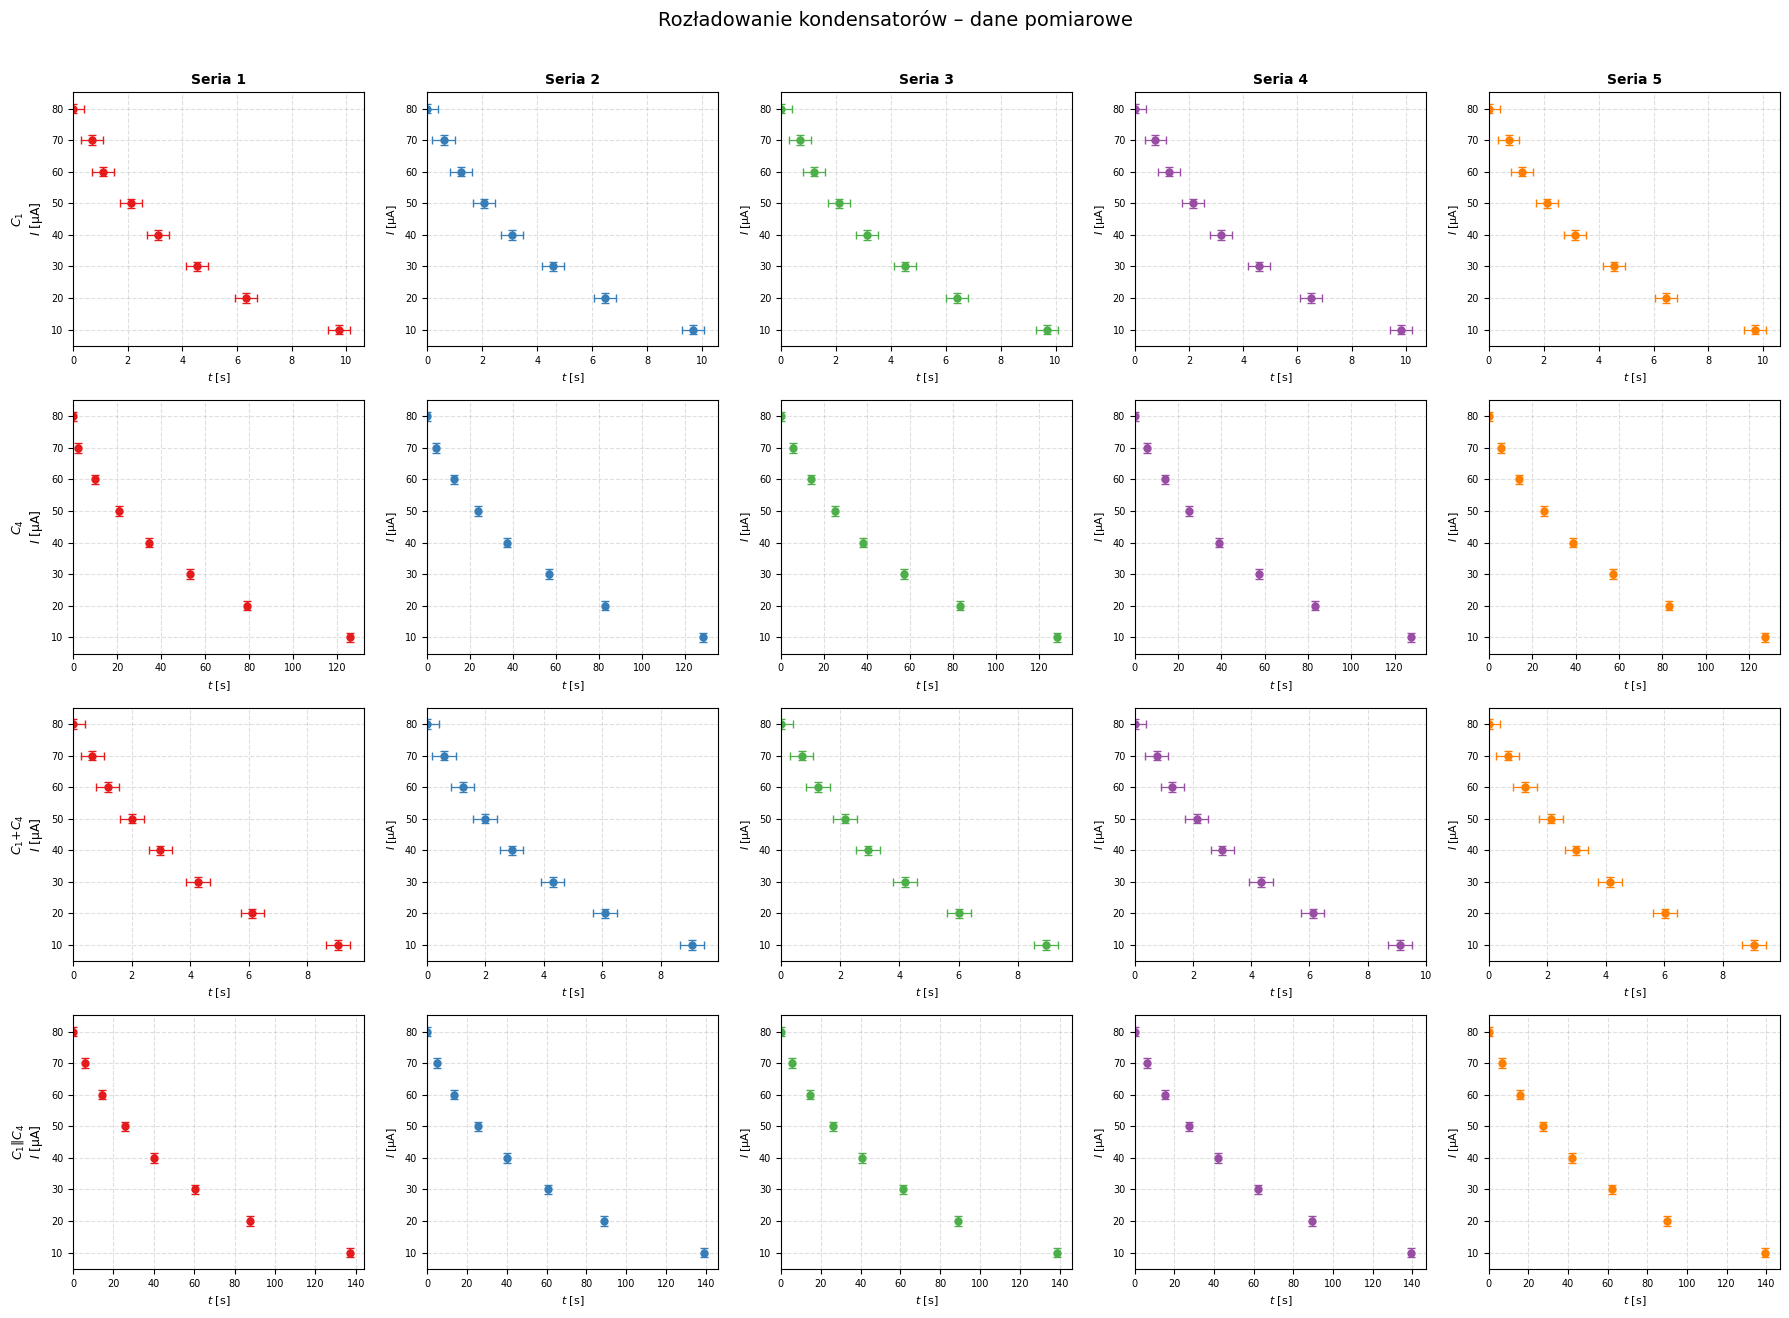

Zapisano wykresy_punkty.pdf


In [4]:
# ── Wykres 1: surowe punkty pomiarowe – siatka 4×5 ────────────────────────
fig1, axes1 = plt.subplots(4, 5, figsize=(18, 13))
fig1.suptitle('Rozładowanie kondensatorów – dane pomiarowe', fontsize=14, y=1.01)

for row, (name, short, df) in enumerate(DATASETS_Z):
    for col, (sid, grp) in enumerate(df.groupby('series')):
        ax = axes1[row, col]
        c  = COLORS[col]

        ax.errorbar(grp['t'], grp['I'],
                    xerr=grp['u_t'], yerr=grp['u_I'],
                    fmt='o', color=c, markersize=5,
                    elinewidth=0.9, capsize=3)

        if row == 0:
            ax.set_title(f'Seria {int(sid)}', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{short}\n$I$ [µA]', fontsize=9)
        else:
            ax.set_ylabel('$I$ [µA]', fontsize=8)
        ax.set_xlabel('$t$ [s]', fontsize=8)
        ax.set_xlim(left=0)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(labelsize=7)

plt.tight_layout()
with PdfPages('wykresy_punkty.pdf') as pdf:
    pdf.savefig(fig1, bbox_inches='tight')
plt.show()
print('Zapisano wykresy_punkty.pdf')

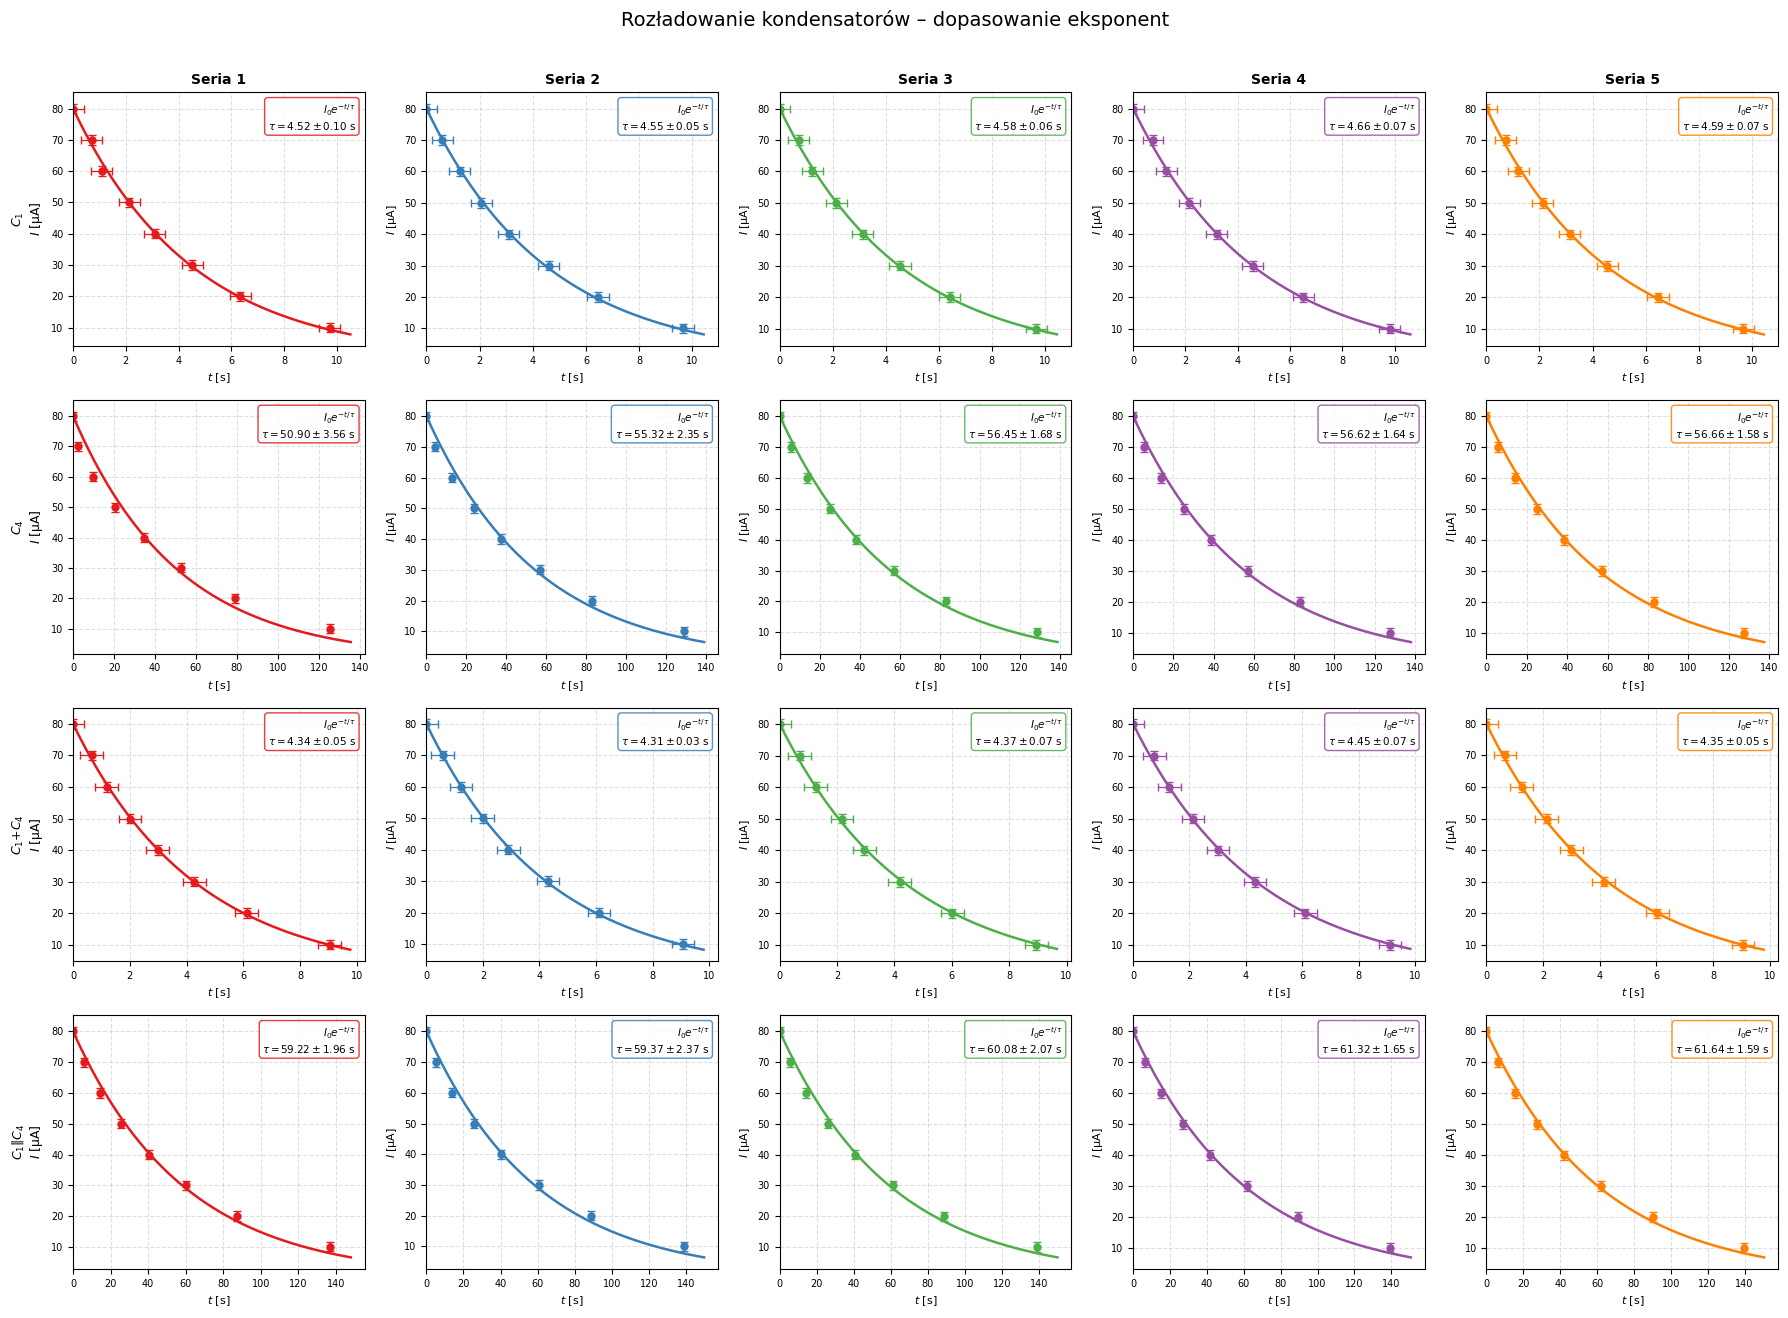

Zapisano wykresy_eksponenty.pdf


In [5]:
# ── Wykres 2: dopasowanie eksponenty – siatka 4×5 ─────────────────────────
fig2, axes2 = plt.subplots(4, 5, figsize=(18, 13))
fig2.suptitle('Rozładowanie kondensatorów – dopasowanie eksponent', fontsize=14, y=1.01)

for row, (name, short, df) in enumerate(DATASETS_Z):
    for col, (sid, grp) in enumerate(df.groupby('series')):
        ax = axes2[row, col]
        c  = COLORS[col]

        ax.errorbar(grp['t'], grp['I'],
                    xerr=grp['u_t'], yerr=grp['u_I'],
                    fmt='o', color=c, markersize=5,
                    elinewidth=0.9, capsize=3)

        result = fit_exp(grp)
        if result:
            tau_val, u_tau = result
            t_fit = np.linspace(0, grp['t'].max() * 1.08, 400)
            ax.plot(t_fit, exp_decay(t_fit, tau_val), color=c, linewidth=1.8)
            ax.text(0.97, 0.96,
                    f'$I_0 e^{{-t/\\tau}}$\n'
                    f'$\\tau = {tau_val:.2f} \\pm {u_tau:.2f}$ s',
                    transform=ax.transAxes, fontsize=7.5,
                    va='top', ha='right',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor=c, alpha=0.85))

        if row == 0:
            ax.set_title(f'Seria {int(sid)}', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{short}\n$I$ [µA]', fontsize=9)
        else:
            ax.set_ylabel('$I$ [µA]', fontsize=8)
        ax.set_xlabel('$t$ [s]', fontsize=8)
        ax.set_xlim(left=0)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(labelsize=7)

plt.tight_layout()
with PdfPages('wykresy_eksponenty.pdf') as pdf:
    pdf.savefig(fig2, bbox_inches='tight')
plt.show()
print('Zapisano wykresy_eksponenty.pdf')

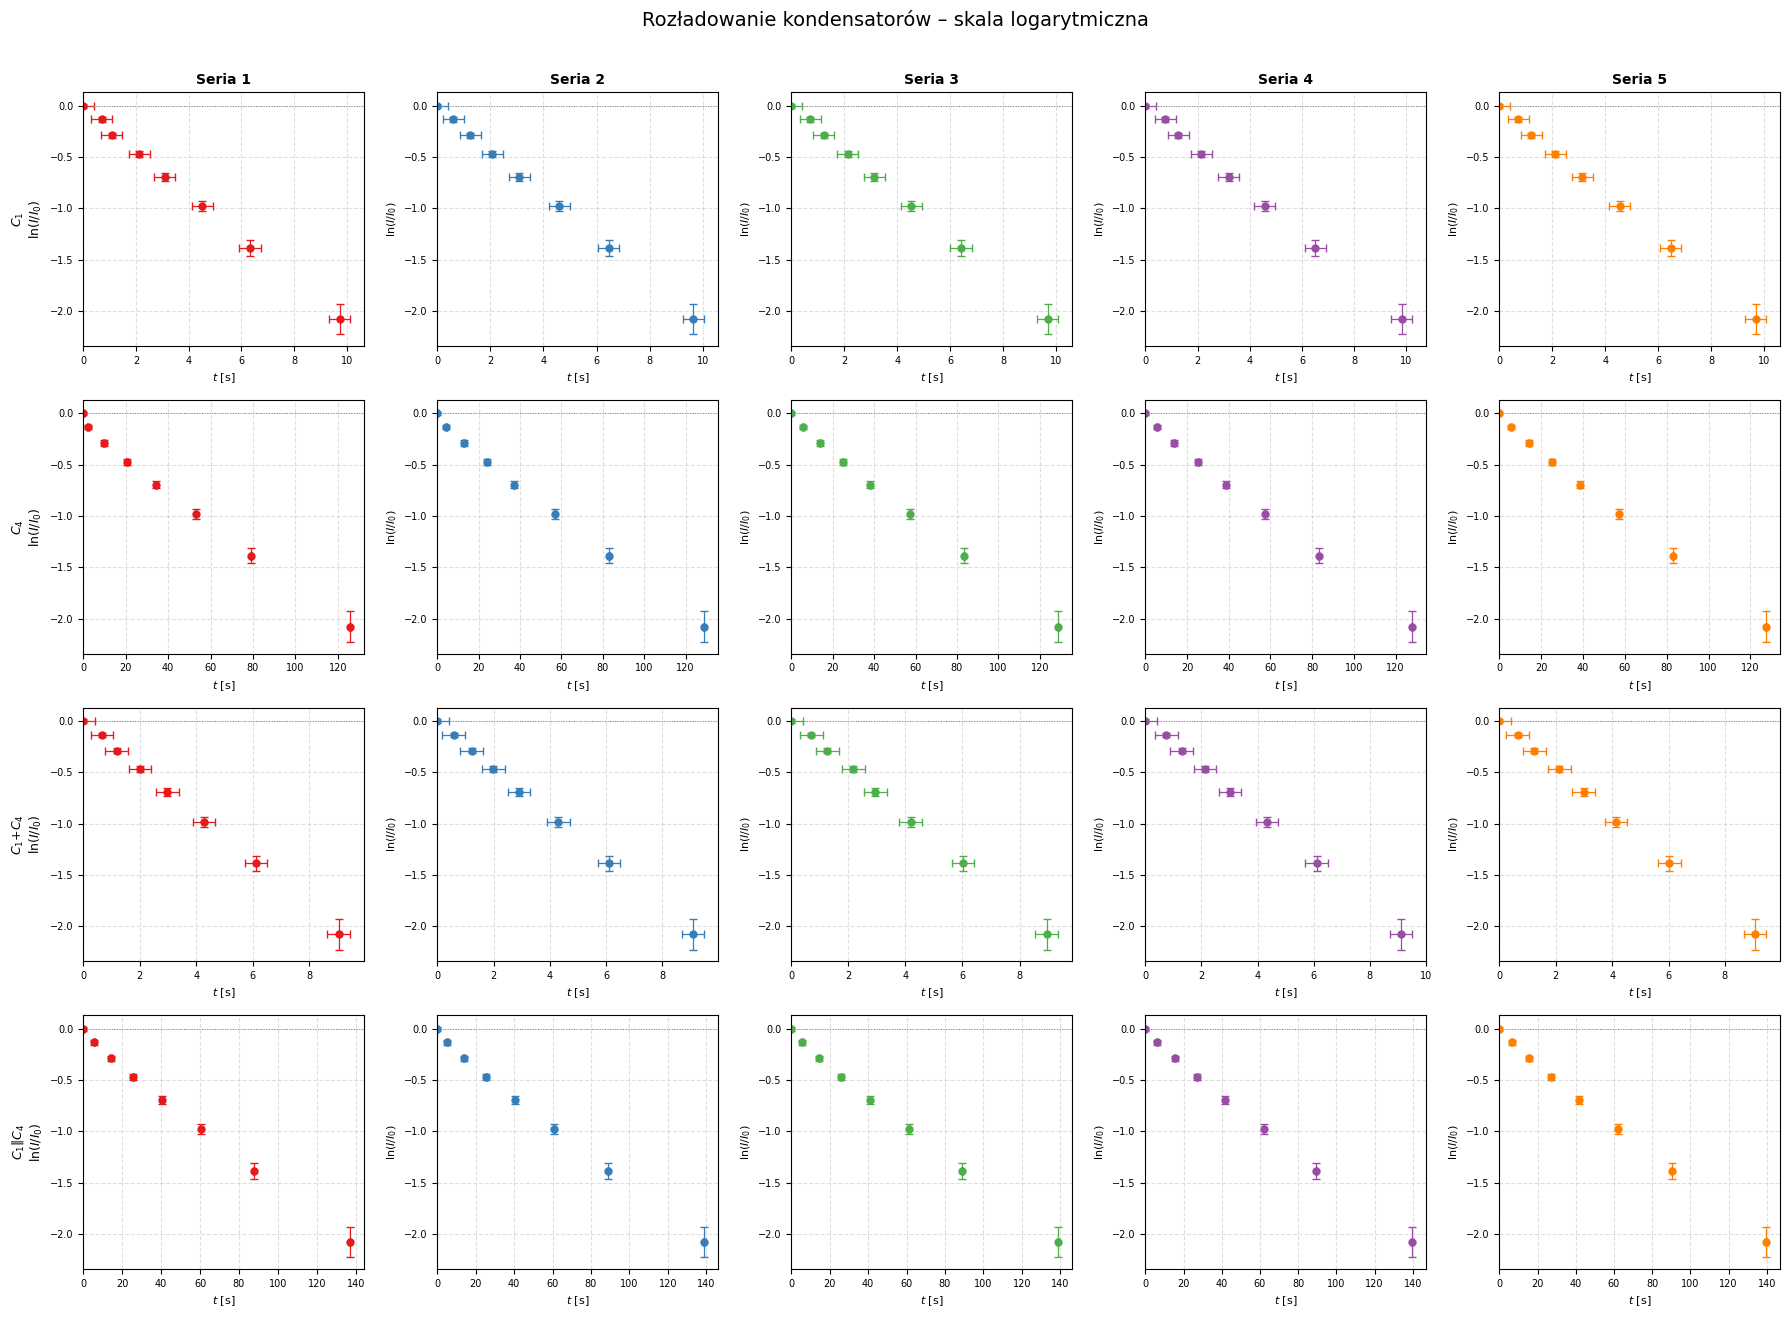

Zapisano wykresy_log.pdf


In [6]:
# ── Wykres 3: ln(I/I₀) – dane bez regresji – siatka 4×5 ──────────────────
#   u(ln(I/I₀)) = u_I / I

fig3, axes3 = plt.subplots(4, 5, figsize=(18, 13))
fig3.suptitle('Rozładowanie kondensatorów – skala logarytmiczna', fontsize=14, y=1.01)

for row, (name, short, df) in enumerate(DATASETS_LOG):
    for col, (sid, grp) in enumerate(df.groupby('series')):
        ax = axes3[row, col]
        c  = COLORS[col]

        ax.errorbar(grp['t'], grp['ln_ratio'],
                    xerr=grp['u_t'], yerr=grp['u_ln'],
                    fmt='o', color=c, markersize=5,
                    elinewidth=0.9, capsize=3)

        ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
        if row == 0:
            ax.set_title(f'Seria {int(sid)}', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{short}\n$\\ln(I/I_0)$', fontsize=9)
        else:
            ax.set_ylabel(r'$\ln(I/I_0)$', fontsize=8)
        ax.set_xlabel('$t$ [s]', fontsize=8)
        ax.set_xlim(left=0)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(labelsize=7)

plt.tight_layout()
with PdfPages('wykresy_log.pdf') as pdf:
    pdf.savefig(fig3, bbox_inches='tight')
plt.show()
print('Zapisano wykresy_log.pdf')

In [ ]:
# ── Wykres 4: ln(I/I₀) – regresja liniowa – siatka 4×5 ───────────────────
#   Model:  ln(I/I₀) = slope·t + b,  slope = -1/τ
#   u_τ = u_slope / slope²  (różniczka zupełna)

fig4, axes4 = plt.subplots(4, 5, figsize=(18, 13))
fig4.suptitle('Rozładowanie kondensatorów – regresja liniowa (skala log)', fontsize=14, y=1.01)

for row, (name, short, df) in enumerate(DATASETS_LOG):
    for col, (sid, grp) in enumerate(df.groupby('series')):
        ax = axes4[row, col]
        c  = COLORS[col]

        ax.errorbar(grp['t'], grp['ln_ratio'],
                    xerr=grp['u_t'], yerr=grp['u_ln'],
                    fmt='o', color=c, markersize=5,
                    elinewidth=0.9, capsize=3)

        result = fit_lin(grp)
        if result:
            slope, u_slope, intercept, tau_val, u_tau = result
            t_fit = np.linspace(0, grp['t'].max() * 1.08, 400)
            ax.plot(t_fit, linear(t_fit, slope, intercept), color=c, linewidth=1.8)
            ax.text(0.97, 0.96,
                    f'$a = {slope:.4f} \\pm {u_slope:.4f}$ s$^{{-1}}$\n'
                    f'$\\tau = {tau_val:.2f} \\pm {u_tau:.2f}$ s',
                    transform=ax.transAxes, fontsize=7.5,
                    va='top', ha='right',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor=c, alpha=0.85))

        ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
        if row == 0:
            ax.set_title(f'Seria {int(sid)}', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{short}\n$\\ln(I/I_0)$', fontsize=9)
        else:
            ax.set_ylabel(r'$\ln(I/I_0)$', fontsize=8)
        ax.set_xlabel('$t$ [s]', fontsize=8)
        ax.set_xlim(left=0)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(labelsize=7)

plt.tight_layout()
with PdfPages('wykresy_log_regresja.pdf') as pdf:
    pdf.savefig(fig4, bbox_inches='tight')
plt.show()
print('Zapisano wykresy_log_regresja.pdf')

In [ ]:
# ── Obliczenia pojemności i ładunków ───────────────────────────────────────

LABELS = ['C1', 'C4', 'C1C4_ser', 'C1C4_par']
PRETTY = [r'$C_1$', r'$C_4$', r'$C_1{+}C_4$ (szer.)', r'$C_1{\|}C_4$ (rów.)']

def weighted_mean(vals, u_vals):
    """Ważona średnia i jej niepewność."""
    w = 1.0 / np.array(u_vals, dtype=float)**2
    mean = np.sum(w * np.array(vals, dtype=float)) / np.sum(w)
    u_mean = 1.0 / np.sqrt(np.sum(w))
    return mean, u_mean

def cap_from_tau(tau, u_tau, R_val, u_R_val):
    """C = τ/R,  u_C różniczką zupełną."""
    C = tau / R_val
    u_C = np.sqrt((u_tau / R_val)**2 + (tau * u_R_val / R_val**2)**2)
    return C, u_C

def fmt_siu(val, u):
    """Formatuj jako X.XXX(YYY) – notacja siunitx dla LaTeX."""
    import math
    dec = max(0, -int(math.floor(math.log10(u))) + 1)
    scaled_u = int(round(u * 10**dec))
    return f'{val:.{dec}f}({scaled_u:03d})'

# ── 1a. Stałe czasowe z regresji liniowej ─────────────────────────────────
tau_data = {}  # label → (tau_mean [s], u_tau_mean [s], [tau_i], [u_tau_i])

for lbl, (name, short, df) in zip(LABELS, DATASETS_LOG):
    taus, u_taus = [], []
    for sid, grp in df.groupby('series'):
        res = fit_lin(grp)
        if res:
            _, _, _, tau_val, u_tau = res
            taus.append(tau_val)
            u_taus.append(u_tau)
    tau_mean, u_tau_mean = weighted_mean(taus, u_taus)
    tau_data[lbl] = (tau_mean, u_tau_mean, taus, u_taus)

print('Stałe czasowe z regresji liniowej (ważona średnia z 5 serii):')
for lbl, pretty in zip(LABELS, PRETTY):
    tau_mean, u_tau_mean, _, _ = tau_data[lbl]
    print(f'  τ_lin[{pretty:30s}] = {tau_mean:8.3f} ± {u_tau_mean:.3f} s')

# ── 1b. Stałe czasowe z dopasowania eksponenty ────────────────────────────
tau_exp_data = {}  # label → (tau_mean [s], u_tau_mean [s], [tau_i], [u_tau_i])

for lbl, (name, short, df) in zip(LABELS, DATASETS_Z):
    taus, u_taus = [], []
    for sid, grp in df.groupby('series'):
        res = fit_exp(grp)
        if res:
            tau_val, u_tau = res
            taus.append(tau_val)
            u_taus.append(u_tau)
    tau_mean, u_tau_mean = weighted_mean(taus, u_taus)
    tau_exp_data[lbl] = (tau_mean, u_tau_mean, taus, u_taus)

print('\nStałe czasowe z dopasowania eksponenty (ważona średnia z 5 serii):')
for lbl, pretty in zip(LABELS, PRETTY):
    tau_mean, u_tau_mean, _, _ = tau_exp_data[lbl]
    print(f'  τ_exp[{pretty:30s}] = {tau_mean:8.3f} ± {u_tau_mean:.3f} s')

# ── 1c. Porównanie obu metod (format siunitx do wklejenia do LaTeX) ───────
print('\nPorównanie metod – format siunitx dla tab:tau w LaTeX:')
print(f'  {"Układ":12}  {"τ_lin":>14}  {"τ_exp":>14}')
for lbl, pretty in zip(LABELS, PRETTY):
    tl, utl, _, _ = tau_data[lbl]
    te, ute, _, _ = tau_exp_data[lbl]
    print(f'  {lbl:12s}  {fmt_siu(tl, utl):>14}  {fmt_siu(te, ute):>14}')

# ── 2. Pojemności z regresji liniowej (C = τ_lin / R) ─────────────────────
print('\nPojemności z regresji liniowej (C = τ_lin/R):')
C_fit = {}

for lbl, pretty in zip(LABELS, PRETTY):
    tau_mean, u_tau_mean, _, _ = tau_data[lbl]
    C, u_C = cap_from_tau(tau_mean, u_tau_mean, R, u_R)
    C_fit[lbl] = (C, u_C)
    print(f'  C[{pretty:30s}] = ({C*1e6:.4f} ± {u_C*1e6:.4f}) µF')

# ── 3. Pojemności zastępcze ze wzorów ─────────────────────────────────────
C1,  uC1  = C_fit['C1']
C4,  uC4  = C_fit['C4']

C_r_wzor  = C1 + C4
uC_r_wzor = np.sqrt(uC1**2 + uC4**2)

C_s_wzor  = 1.0 / (1.0/C1 + 1.0/C4)
uC_s_wzor = C_s_wzor**2 * np.sqrt((uC1/C1**2)**2 + (uC4/C4**2)**2)

print('\nPojemności zastępcze – porównanie metod:')
print(f'  C_r (wzór C1+C4)       = ({C_r_wzor*1e6:.4f} ± {uC_r_wzor*1e6:.4f}) µF')
print(f'  C_r (fit)              = ({C_fit["C1C4_par"][0]*1e6:.4f} ± {C_fit["C1C4_par"][1]*1e6:.4f}) µF')
print()
print(f'  C_s (wzór 1/C1+1/C4)  = ({C_s_wzor*1e6:.4f} ± {uC_s_wzor*1e6:.4f}) µF')
print(f'  C_s (fit)              = ({C_fit["C1C4_ser"][0]*1e6:.4f} ± {C_fit["C1C4_ser"][1]*1e6:.4f}) µF')

# ── 4. Ładunek q = τ_lin · I₀,  u_q różniczką zupełną ────────────────────
# q = τ · I₀  →  u_q = sqrt((I₀·u_τ)² + (τ·u_I)²)
u_I_val = 1.5  # µA – niepewność wskazania mikroamperomierza

print(f'\nŁadunek zgromadzony q = τ_lin · I₀  (I₀ = {I0} µA, u_I = {u_I_val} µA):')
for lbl, pretty in zip(LABELS, PRETTY):
    tau_mean, u_tau_mean, _, _ = tau_data[lbl]
    q   = tau_mean * I0
    u_q = np.sqrt((I0 * u_tau_mean)**2 + (tau_mean * u_I_val)**2)
    print(f'  q[{pretty:30s}] = ({q:.4f} ± {u_q:.4f}) µC')